## Gene Sentence Length

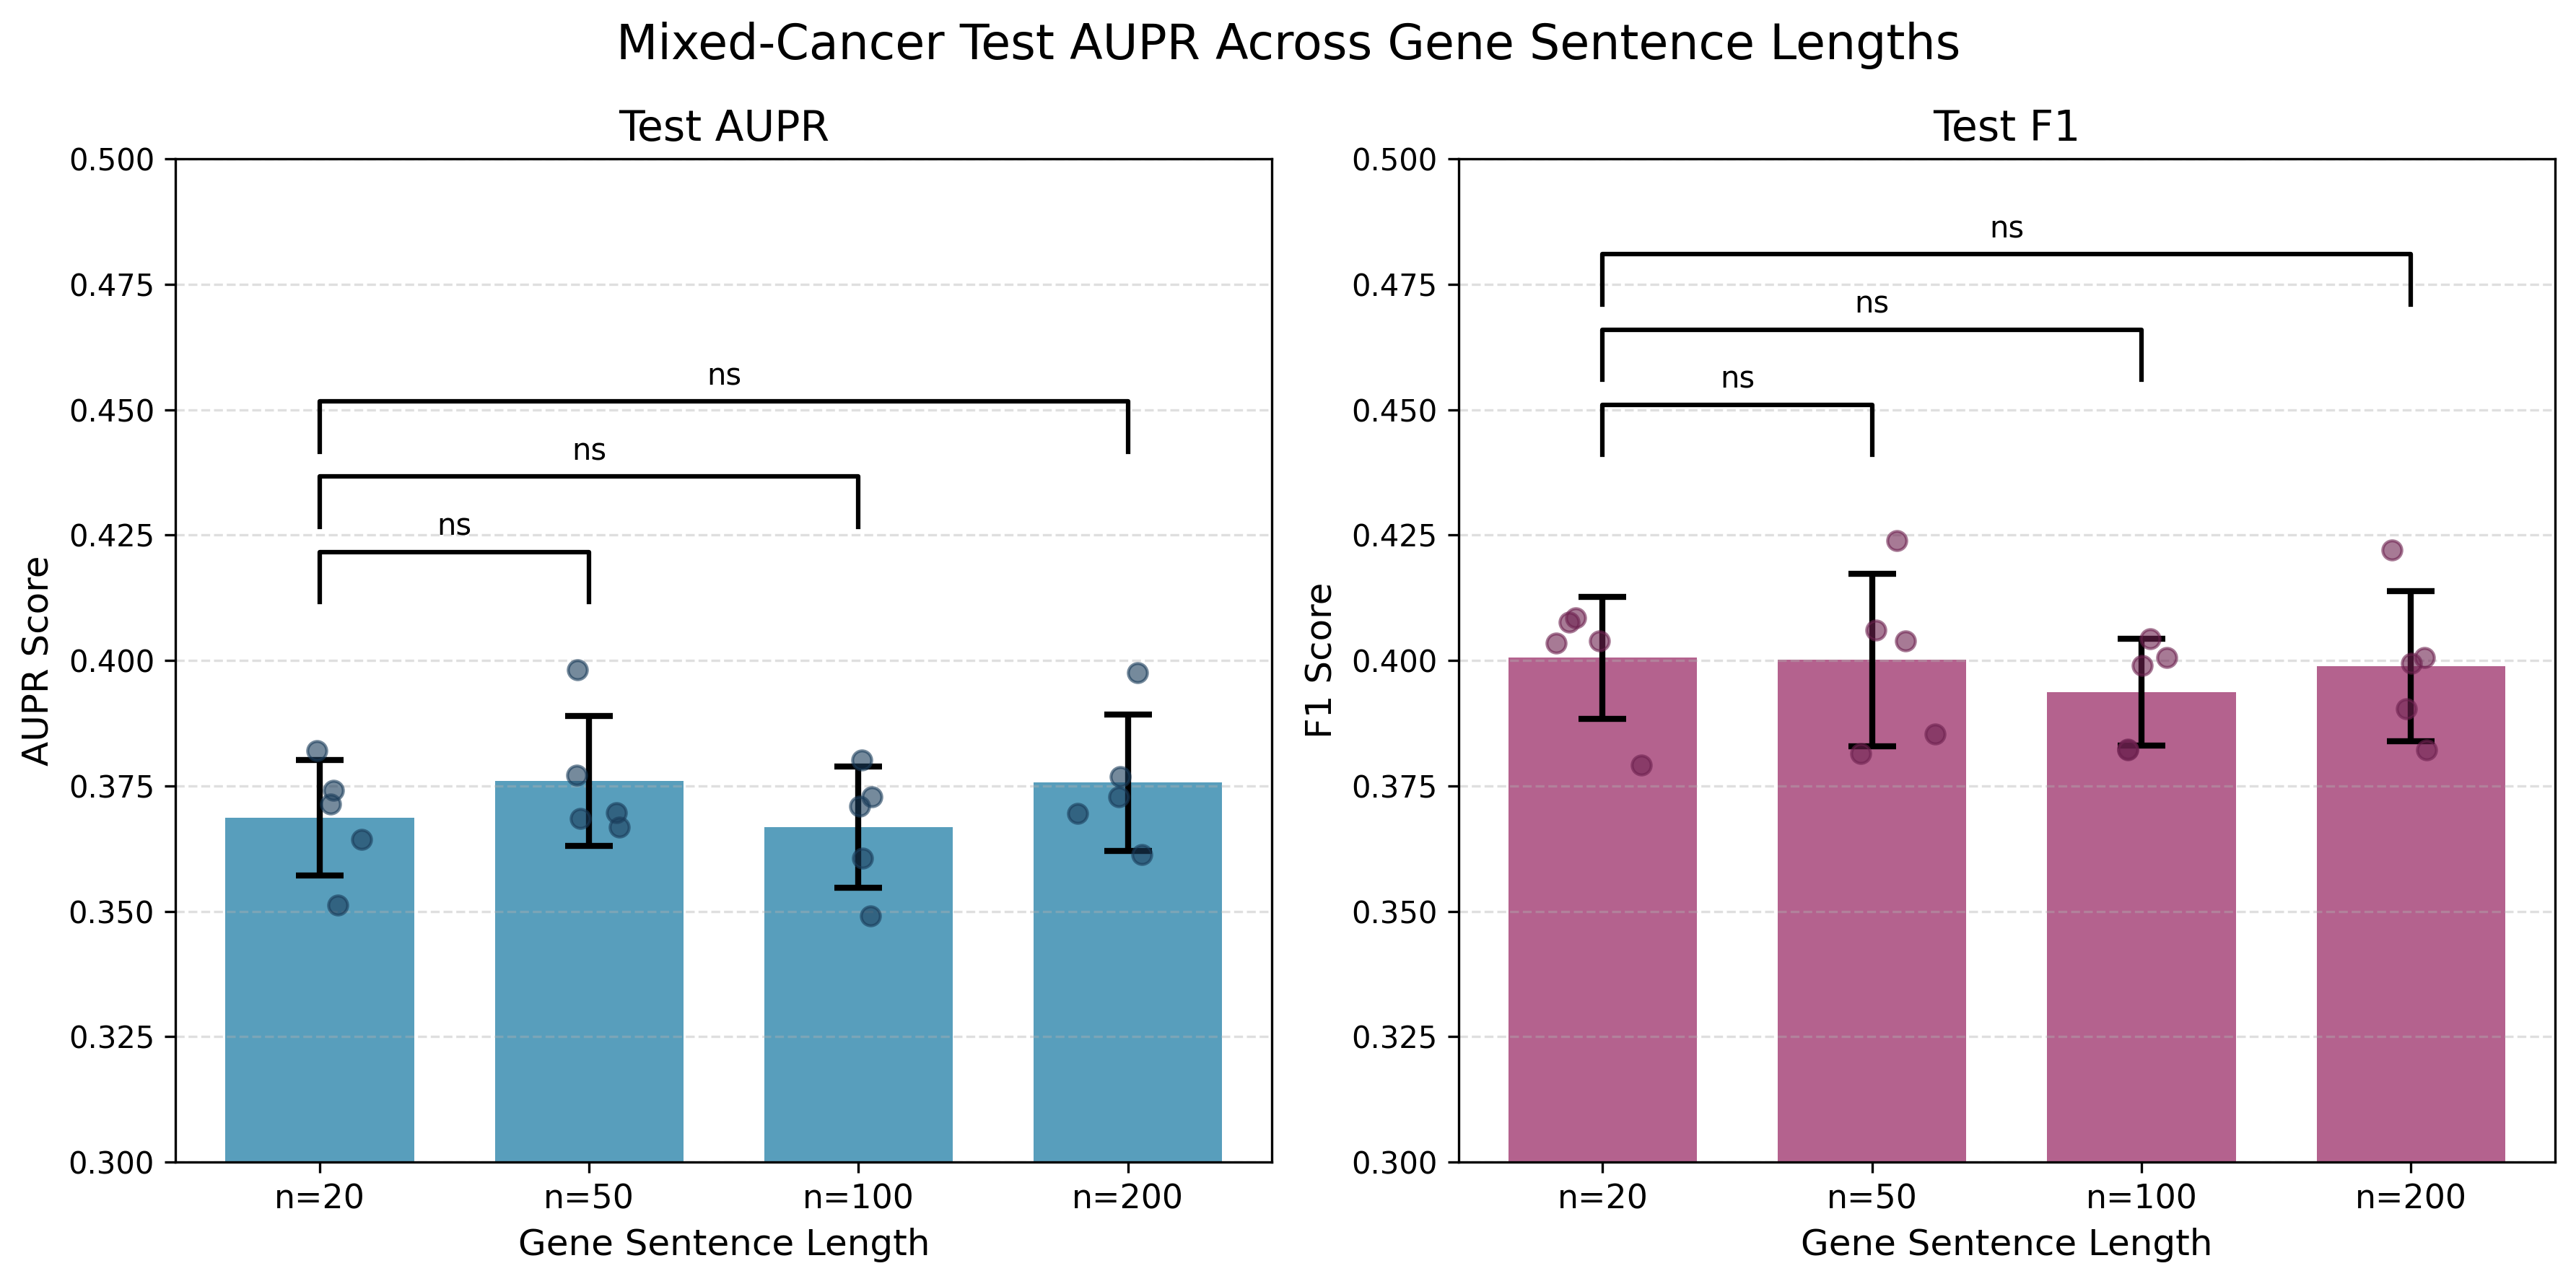

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import matplotlib

# ---- Raw Data ----
n20_aupr = [0.3741543376542424, 0.3819668584642034, 0.35130339906091423, 0.3643636105717097, 0.3713537664749212]
n20_f1 = [0.4085213032581454, 0.40396530359355637, 0.3791208791208791, 0.4076923076923077, 0.40343347639484983]

n50_aupr = [0.3981031185944664, 0.37708025042165305, 0.36850851871805307, 0.36962355743593517, 0.36674497361278074]
n50_f1 = [0.42382588774341345, 0.406015037593985, 0.38144329896907214, 0.4038694074969771, 0.3854014598540146]

n100_aupr = [0.3728512601347151, 0.380132690171057, 0.37092996888292307, 0.34911467098253224, 0.3606469286404372]
n100_f1 = [0.4043126684636118, 0.40057224606580827, 0.38227848101265827, 0.38218053927315354, 0.39893617021276595]

n200_aupr = [0.3769191541934094, 0.39760671780768836, 0.36954416967920756, 0.36131343812841477, 0.37275931004798424]
n200_f1 = [0.4005486968449931, 0.4220430107526882, 0.3903559127439724, 0.3821138211382114, 0.399421128798]

aupr_data = {
    20: n20_aupr,
    50: n50_aupr,
    100: n100_aupr,
    200: n200_aupr
}

f1_data = {
    20: n20_f1,
    50: n50_f1,
    100: n100_f1,
    200: n200_f1
}

lengths = [20, 50, 100, 200]

normal_aupr_mean = [np.mean(aupr_data[n]) for n in lengths]
normal_aupr_std = [np.std(aupr_data[n], ddof=1) for n in lengths]

normal_f1_mean = [np.mean(f1_data[n]) for n in lengths]
normal_f1_std = [np.std(f1_data[n], ddof=1) for n in lengths]

def calculate_pairwise_pvalues(data_dict):
    groups = list(data_dict.keys())
    pvalues = {}
    for i in range(len(groups)):
        for j in range(i+1, len(groups)):
            group1, group2 = groups[i], groups[j]
            t_stat, p_val = ttest_ind(data_dict[group1], data_dict[group2])
            pvalues[f"{group1}-{group2}"] = p_val
    return pvalues

aupr_pvalues = calculate_pairwise_pvalues(aupr_data)
f1_pvalues = calculate_pairwise_pvalues(f1_data)

def add_significance_bars(ax, x_positions, pvalues, y_max, h=0.01, step=0.015):
    pairs = sorted(pvalues.keys(), key=lambda k: (int(k.split('-')[0]), int(k.split('-')[1])))

    def get_sig_label(p):
        if p < 0.001:
            return '***'
        elif p < 0.01:
            return '**'
        elif p < 0.05:
            return '*'
        else:
            return 'ns'

    for idx, key in enumerate(pairs):
        g1, g2 = map(int, key.split('-'))
        p = pvalues[key]
        sig = get_sig_label(p)

        x1 = list(aupr_data.keys()).index(g1)
        x2 = list(aupr_data.keys()).index(g2)
        y = y_max + idx * step

        ax.plot([x_positions[x1], x_positions[x1], x_positions[x2], x_positions[x2]],
                [y, y + h, y + h, y], lw=1.5, c='k')
        ax.text((x_positions[x1] + x_positions[x2]) / 2, y + h + 0.002, sig,
                ha='center', va='bottom', color='k', fontsize=10)


x = np.arange(len(lengths))

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=300)
fig.suptitle('Effect of Gene Sentence Length on Model Performance (Mixed Cancer)', 
             fontsize=16)

# -------- Left: AUPR --------
ax = axes[0]
bars = ax.bar(x, normal_aupr_mean, width=0.7, 
       yerr=normal_aupr_std, capsize=8, color='#2E86AB', alpha=0.8,
       error_kw={'elinewidth': 2, 'markeredgewidth': 2})

for i, n in enumerate(lengths):
    y_points = aupr_data[n]
    x_points = np.random.normal(i, 0.08, size=len(y_points))
    ax.scatter(x_points, y_points, color='#1A3C5A', alpha=0.6, s=40, zorder=3)

aupr_y_max = max([max(aupr_data[n]) for n in lengths]) + max(normal_aupr_std)

aupr_pvalues_first = {k: v for k, v in aupr_pvalues.items() if k.startswith('20-')}
f1_pvalues_first = {k: v for k, v in f1_pvalues.items() if k.startswith('20-')}

add_significance_bars(ax, x, aupr_pvalues_first, aupr_y_max)


ax.set_title('Test AUPR', fontsize=14)
ax.set_ylabel('AUPR Score', fontsize=12)
ax.set_xlabel('Gene Sentence Length', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([f'n={n}' for n in lengths], fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_ylim(0.3, 0.5)

# -------- Right: F1 --------
ax = axes[1]
bars = ax.bar(x, normal_f1_mean, width=0.7, 
       yerr=normal_f1_std, capsize=8, color='#A23B72', alpha=0.8,
       error_kw={'elinewidth': 2, 'markeredgewidth': 2})

for i, n in enumerate(lengths):
    y_points = f1_data[n]
    x_points = np.random.normal(i, 0.08, size=len(y_points))
    ax.scatter(x_points, y_points, color='#6D214F', alpha=0.6, s=40, zorder=3)

f1_y_max = max([max(f1_data[n]) for n in lengths]) + max(normal_f1_std)
add_significance_bars(ax, x, f1_pvalues_first, f1_y_max)

ax.set_title('Test F1', fontsize=14)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_xlabel('Gene Sentence Length', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([f'n={n}' for n in lengths], fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_ylim(0.3, 0.5)

plt.tight_layout()
plt.savefig('statistical_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## Cancer specific


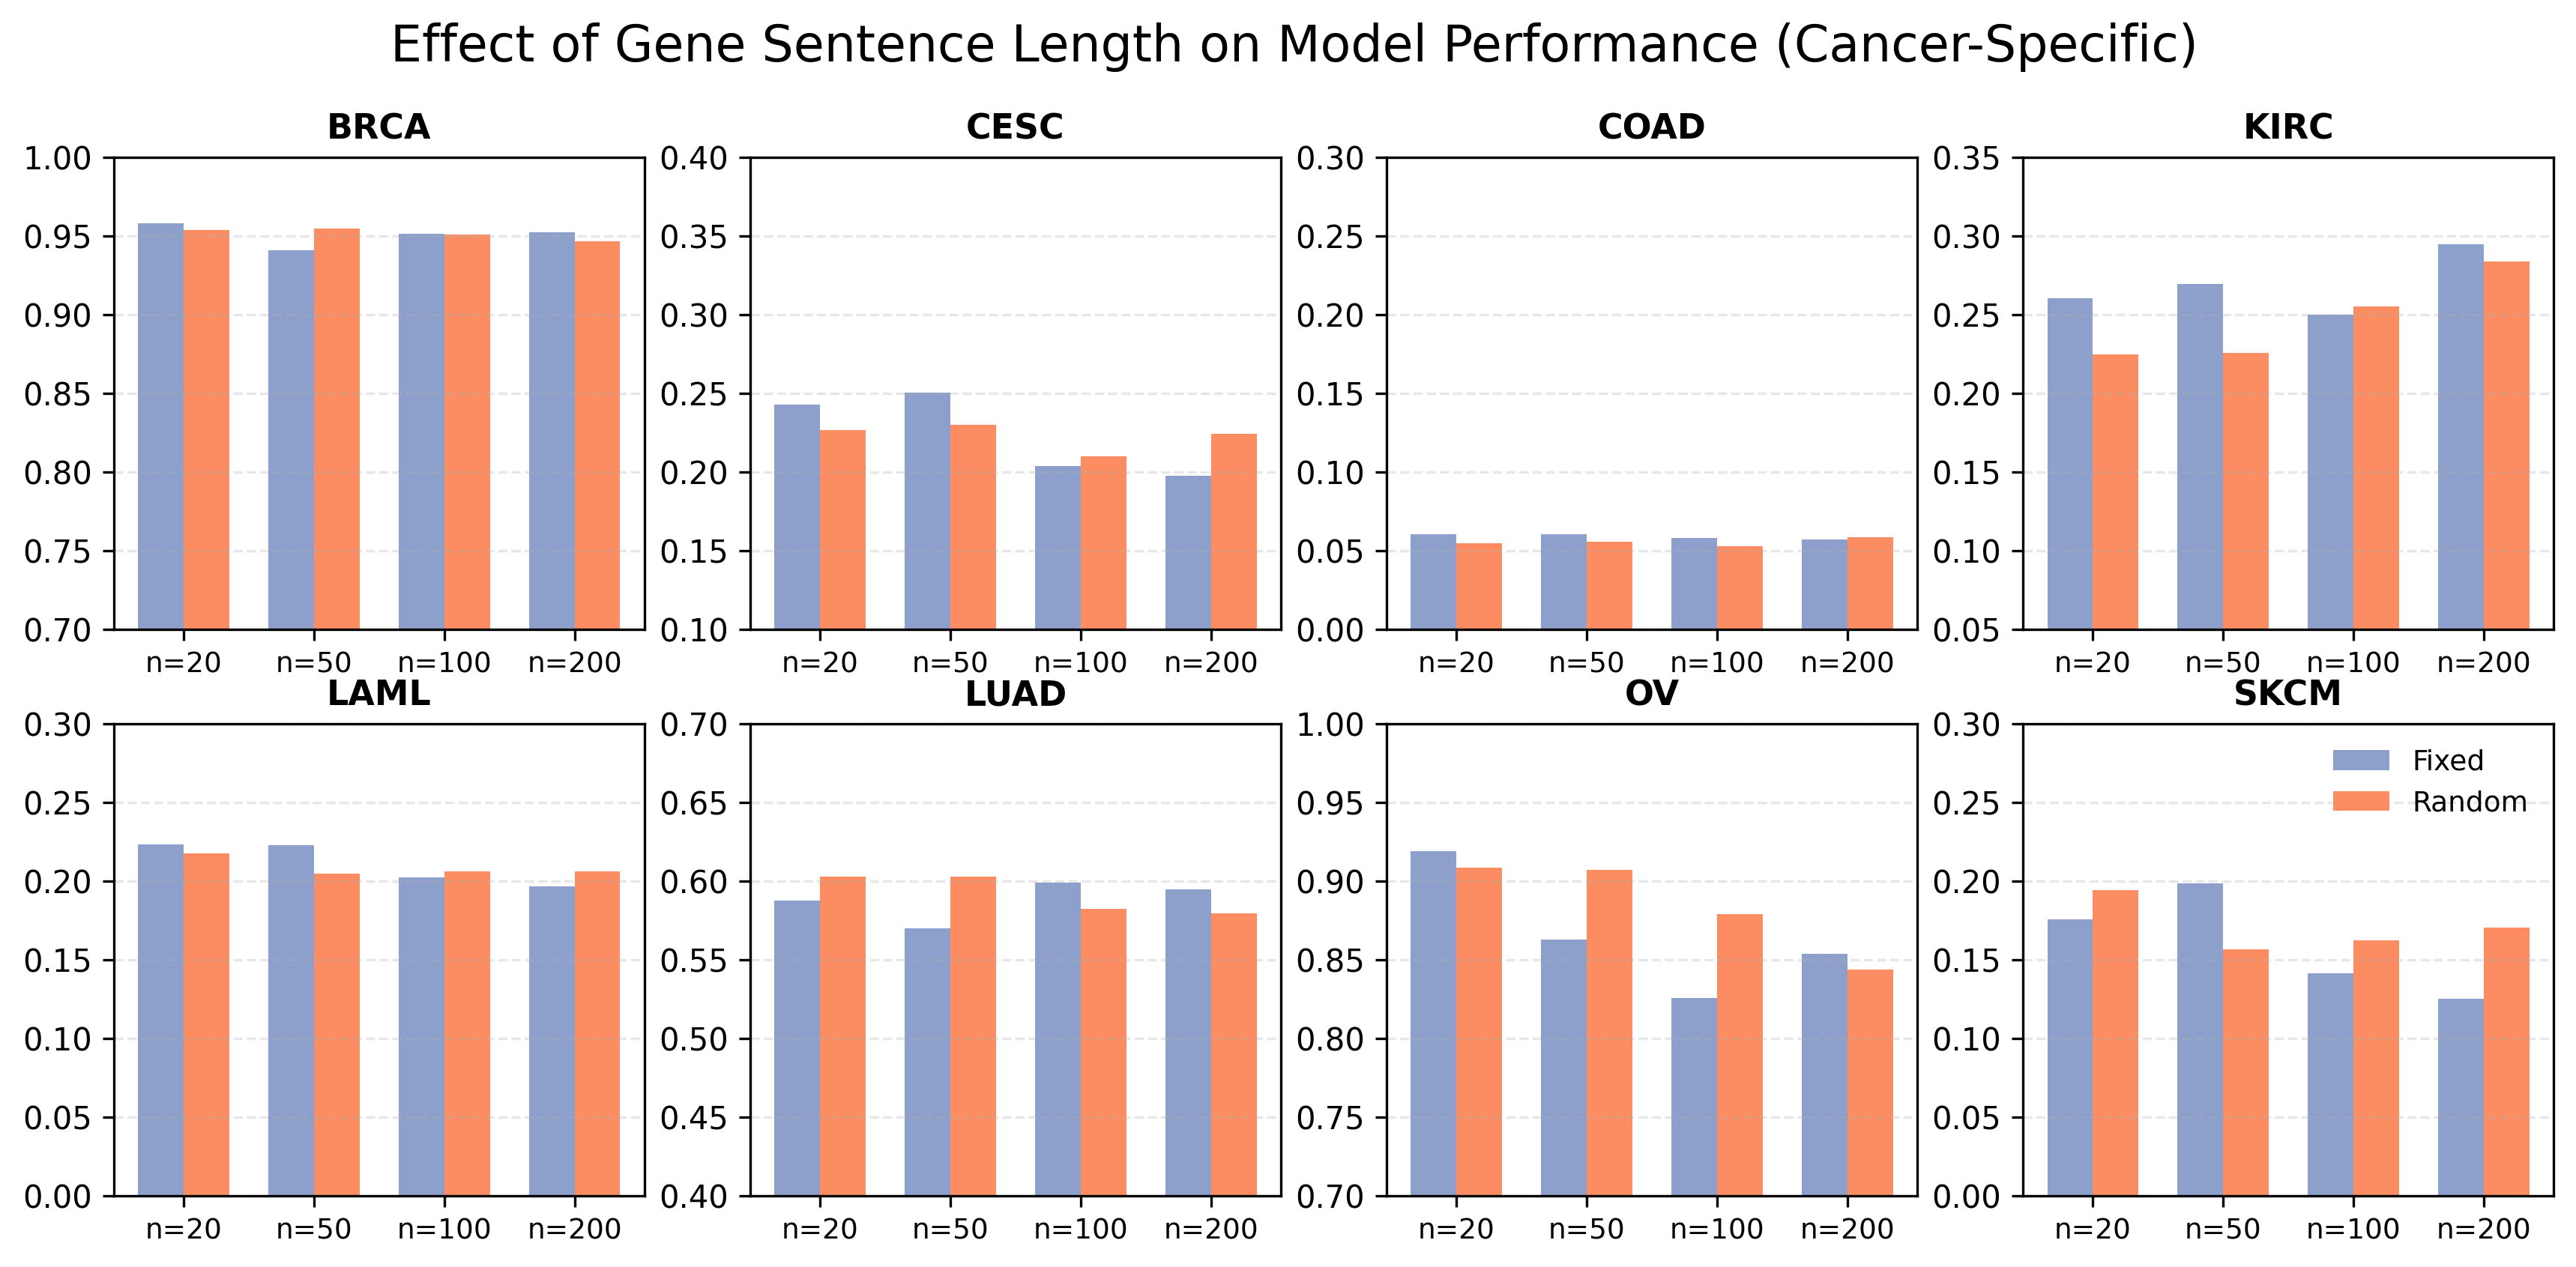

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Data setup
# ------------------------------------------------
cancers = ["BRCA", "CESC", "COAD", "KIRC", "LAML", "LUAD", "OV", "SKCM"]
lengths = [20, 50, 100, 200]

# mean (AUPR)
fix_mean = {
    "BRCA": [0.9582, 0.9409, 0.9512, 0.9522],
    "CESC": [0.2427, 0.2502, 0.2037, 0.1976],
    "COAD": [0.0604, 0.0606, 0.0581, 0.0570],
    "KIRC": [0.2604, 0.2694, 0.2500, 0.2948],
    "LAML": [0.2234, 0.2230, 0.2022, 0.1967],
    "LUAD": [0.5876, 0.5699, 0.5992, 0.5948],
    "OV":   [0.9189, 0.8630, 0.8256, 0.8537],
    "SKCM": [0.1758, 0.1986, 0.1413, 0.1252],
}

fix_std = {
    "BRCA": [0.0148, 0.0261, 0.0199, 0.0229],
    "CESC": [0.0665, 0.0452, 0.0292, 0.0538],
    "COAD": [0.0124, 0.0104, 0.0093, 0.0116],
    "KIRC": [0.1747, 0.1322, 0.2197, 0.1440],
    "LAML": [0.0290, 0.0206, 0.0218, 0.0219],
    "LUAD": [0.0292, 0.0317, 0.0504, 0.0506],
    "OV":   [0.0552, 0.0952, 0.0919, 0.0887],
    "SKCM": [0.0903, 0.0711, 0.0666, 0.0976],
}

random_mean = {
    "BRCA": [0.9539, 0.9546, 0.9508, 0.9468],
    "CESC": [0.2266, 0.2301, 0.2097, 0.2243],
    "COAD": [0.0548, 0.0556, 0.0528, 0.0587],
    "KIRC": [0.2249, 0.2254, 0.2551, 0.2838],
    "LAML": [0.2174, 0.2049, 0.2061, 0.2063],
    "LUAD": [0.6028, 0.6026, 0.5825, 0.5794],
    "OV":   [0.9084, 0.9069, 0.8788, 0.8435],
    "SKCM": [0.1941, 0.1564, 0.1624, 0.1703],
}

random_std = {
    "BRCA": [0.0190, 0.0138, 0.0188, 0.0164],
    "CESC": [0.0538, 0.0812, 0.0713, 0.0422],
    "COAD": [0.0025, 0.0034, 0.0052, 0.0121],
    "KIRC": [0.1434, 0.1558, 0.1067, 0.1650],
    "LAML": [0.0358, 0.0310, 0.0255, 0.0245],
    "LUAD": [0.0152, 0.0229, 0.0477, 0.0442],
    "OV":   [0.0527, 0.0524, 0.0328, 0.0537],
    "SKCM": [0.0707, 0.0658, 0.0673, 0.0615],
}

# ------------------------------------------------
# Plotting
# ------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(14, 6), dpi=300, sharey=False)
axes = axes.flatten()

bar_width = 0.35
colors = ['#8da0cb', '#fc8d62']

# Define manual y-limits per cancer
ylims = {
    "BRCA": (0.7, 1.00),
    "CESC": (0.10, 0.40),
    "COAD": (0.00, 0.30),
    "KIRC": (0.05, 0.35),
    "LAML": (0.00, 0.30),
    "LUAD": (0.40, 0.70),
    "OV":   (0.70, 1.00),
    "SKCM": (0.00, 0.30),
}

for i, cancer in enumerate(cancers):
    ax = axes[i]
    x = np.arange(len(lengths))
    
    # bars
    ax.bar(x - bar_width/2, fix_mean[cancer], width=bar_width, capsize=3, color=colors[0], label='Fixed') ## yerr=fix_std[cancer]
    ax.bar(x + bar_width/2, random_mean[cancer], width=bar_width, capsize=3, color=colors[1], label='Random') ## yerr=random_std[cancer],
    # ax.bar(x - bar_width/2, fix_mean[cancer], width=bar_width, yerr=fix_std[cancer], capsize=3, color=colors[0], label='Fixed')
    # ax.bar(x + bar_width/2, random_mean[cancer], width=bar_width, yerr=random_std[cancer], capsize=3, color=colors[1], label='Random')
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'n={n}' for n in lengths], fontsize=9)
    ax.set_title(cancer, fontsize=11, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # apply manual y-limits
    if cancer in ylims:
        ax.set_ylim(*ylims[cancer])

# Common legend
axes[-1].legend(frameon=False, loc='upper right', fontsize=9)
fig.suptitle('Effect of Gene Sentence Length on Model Performance (Cancer-Specific)', fontsize=16)
# plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


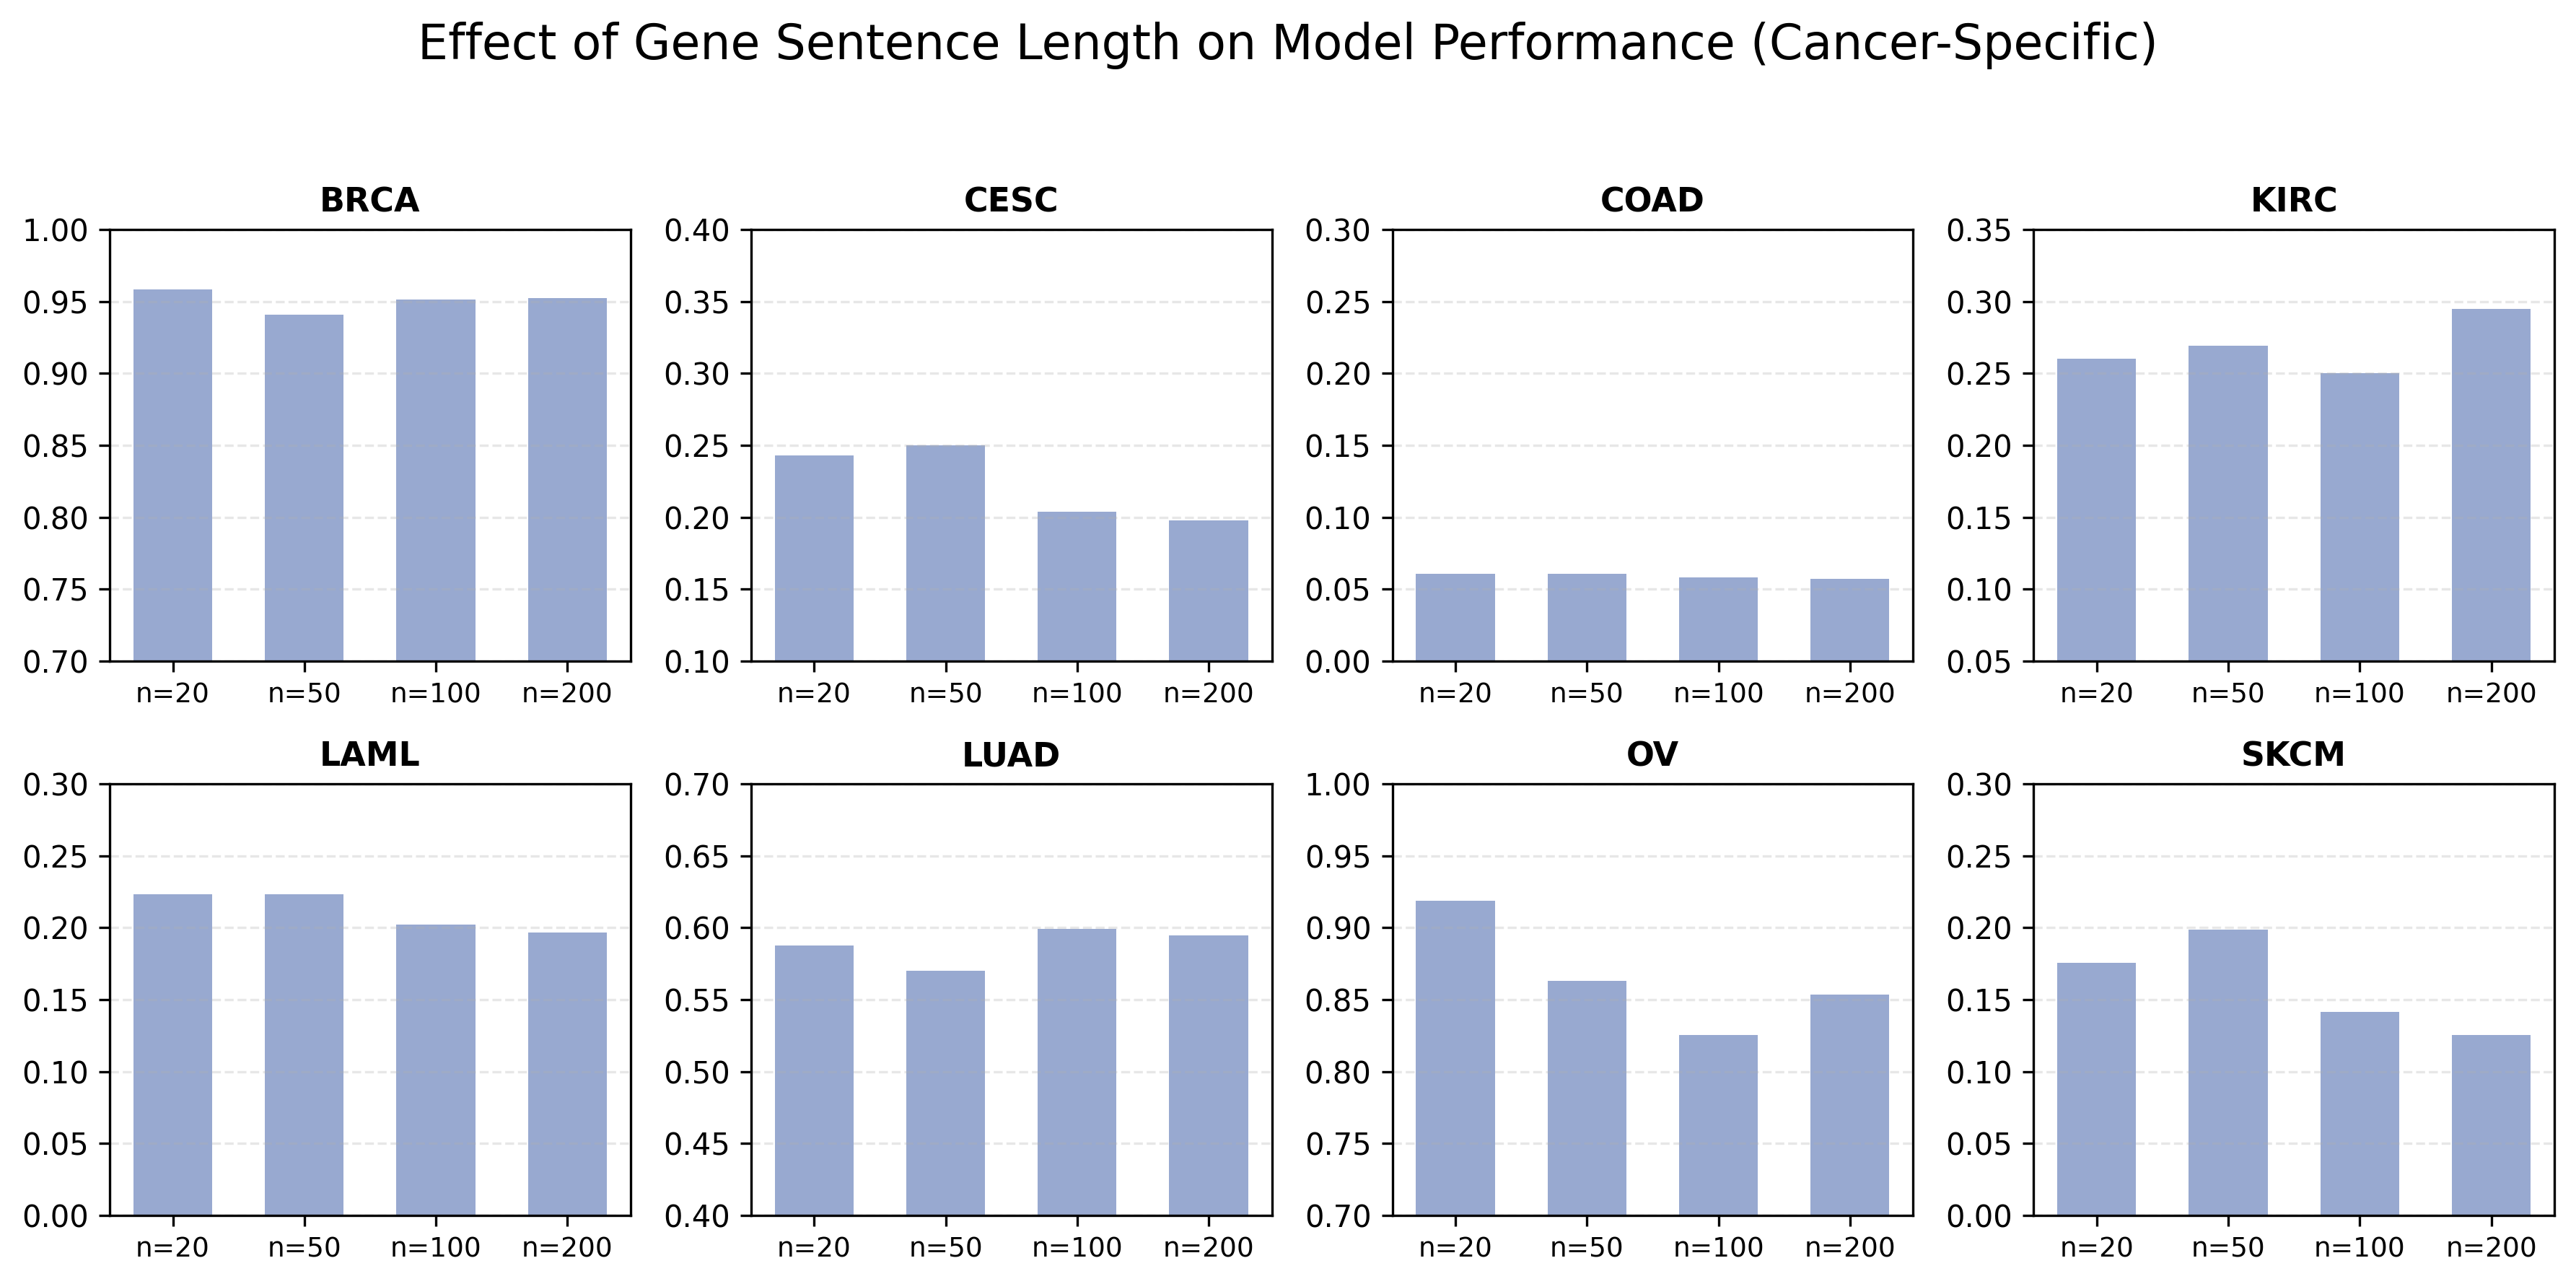

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Data setup
# ------------------------------------------------
cancers = ["BRCA", "CESC", "COAD", "KIRC", "LAML", "LUAD", "OV", "SKCM"]
lengths = [20, 50, 100, 200]

fix_mean = {
    "BRCA": [0.9582, 0.9409, 0.9512, 0.9522],
    "CESC": [0.2427, 0.2502, 0.2037, 0.1976],
    "COAD": [0.0604, 0.0606, 0.0581, 0.0570],
    "KIRC": [0.2604, 0.2694, 0.2500, 0.2948],
    "LAML": [0.2234, 0.2230, 0.2022, 0.1967],
    "LUAD": [0.5876, 0.5699, 0.5992, 0.5948],
    "OV":   [0.9189, 0.8630, 0.8256, 0.8537],
    "SKCM": [0.1758, 0.1986, 0.1413, 0.1252],
}

fix_std = {
    "BRCA": [0.0148, 0.0261, 0.0199, 0.0229],
    "CESC": [0.0665, 0.0452, 0.0292, 0.0538],
    "COAD": [0.0124, 0.0104, 0.0093, 0.0116],
    "KIRC": [0.1747, 0.1322, 0.2197, 0.1440],
    "LAML": [0.0290, 0.0206, 0.0218, 0.0219],
    "LUAD": [0.0292, 0.0317, 0.0504, 0.0506],
    "OV":   [0.0552, 0.0952, 0.0919, 0.0887],
    "SKCM": [0.0903, 0.0711, 0.0666, 0.0976],
}

# ------------------------------------------------
# Plotting
# ------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(12, 6), dpi=300, sharey=False)
axes = axes.flatten()

bar_width = 0.6  
color = '#8da0cb'  

ylims = {
    "BRCA": (0.7, 1.00),
    "CESC": (0.10, 0.40),
    "COAD": (0.00, 0.30),
    "KIRC": (0.05, 0.35),
    "LAML": (0.00, 0.30),
    "LUAD": (0.40, 0.70),
    "OV":   (0.70, 1.00),
    "SKCM": (0.00, 0.30),
}

for i, cancer in enumerate(cancers):
    ax = axes[i]
    x = np.arange(len(lengths))
    
    ax.bar(x, fix_mean[cancer], width=bar_width, 
            capsize=3, color=color, alpha=0.9) #yerr=fix_std[cancer],
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'n={n}' for n in lengths], fontsize=9)
    ax.set_title(cancer, fontsize=11, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    if cancer in ylims:
        ax.set_ylim(*ylims[cancer])

fig.suptitle('Effect of Gene Sentence Length on Model Performance (Cancer-Specific)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()
